In [1]:
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import os
import liana as li
from liana.method import cellphonedb, cellchat
from tqdm import tqdm
#liana dotplot returns a ggsave object...
from plotnine import ggsave, ggplot
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [2]:
folder = "IndividualMiceData/"
Mice = ["GF_HF_6B","GF_HF_13L","SPF_HF_118","SPF_HF_131","SPF_HF_133","GF_HFVHC_5A","GF_HFVHC_16L","SPF_HFVHC_124","SPF_HFVHC_136","SPF_HFVHC_137"]
method = ["CellPhoneDB", "CellChat"]
def get_data():
    data = {}
    for mouse in tqdm(Mice):
        data[mouse] = {}
        for m in method:
            file = folder+mouse+"_"+m+".h5ad"
            data[mouse][m] = sc.read_h5ad(file)
    return data
data = get_data()

100%|██████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:27<00:00,  2.79s/it]


In [37]:
# st = ['Endothelial cells -> Neutrophils','Kupffer cells -> B cells','pDCs -> ILC1s']
# lr = ['Apoe -> Sorl1','Cfh -> Itgam','Tgfb1 -> Cxcr4']
mouse_curr = list(data.keys())[0]
mouse_curr_data = {}
for m in method:
    x = data[mouse_curr][m].uns["cpdb_res"]
    if m == 'CellPhoneDB':
        # x = x[x['lr_means'] != 0]
        x = x[x['cellphone_pvals'] < 0.05]
        x['Ligand_Value'] = x['ligand_means']
        x['Receptor_Value'] = x['receptor_means']
    else:
        # x = x[x['lr_probs'] != 0]
        x = x[x['cellchat_pvals'] < 0.05]
        x['Ligand_Value'] = x['ligand_trimean']
        x['Receptor_Value'] = x['receptor_trimean']
    x = x[['ligand', 'receptor', 'source', 'target', 'Ligand_Value', 'Receptor_Value']]
    x['Source -> Target'] = x['source'] + ' -> ' + x['target']
    x['Ligand -> Receptor'] = x['ligand'] + ' -> ' + x['receptor']
    x['Ligand_Receptor_Difference'] = round(abs(x['Ligand_Value'] - x['Receptor_Value']),3)
    # x = x[x['Source -> Target'].isin(st)]
    # x = x[x['Ligand -> Receptor'].isin(lr)]
    mouse_curr_data[m] = x[['Source -> Target', 'Ligand -> Receptor','Ligand_Receptor_Difference']]

df1 = mouse_curr_data[method[0]]
df2 = mouse_curr_data[method[1]]
    
# Create a combined key for comparison in both DataFrames
df1['combined_key'] = df1['Source -> Target'].astype(str) + '||' + df1['Ligand -> Receptor'].astype(str)
df2['combined_key'] = df2['Source -> Target'].astype(str) + '||' + df2['Ligand -> Receptor'].astype(str)

# Identify the common rows based on the combined key
df_merged = pd.merge(df1, df2, on='combined_key', how='inner')
df_merged['Source -> Target'] = df_merged['Source -> Target_x']
df_merged['Ligand -> Receptor'] = df_merged['Ligand -> Receptor_x']
df_merged['Ligand_Receptor_Difference_CellPhoneDB'] = df_merged['Ligand_Receptor_Difference_x']
df_merged['Ligand_Receptor_Difference_CellChat'] = df_merged['Ligand_Receptor_Difference_y']
df_merged = df_merged[['combined_key', 'Ligand_Receptor_Difference_CellPhoneDB', 'Ligand_Receptor_Difference_CellChat']]
df_merged

,combined_key,Ligand_Receptor_Difference_CellPhoneDB,Ligand_Receptor_Difference_CellChat
0,Kupffer cells -> Neutrophils||Apoe -> Sorl1,0.353,0.086
1,Hepatocytes -> Neutrophils||Apoe -> Sorl1,0.352,0.085
2,Cholangiocytes -> Neutrophils||Spp1 -> Cd44,0.365,0.080
3,Neutrophils -> Endothelial cells||S100a8 -> Cd36,0.593,0.194
4,Neutrophils -> Endothelial cells||S100a9 -> Cd36,0.564,0.185
...,...,...,...
20232,Fibroblasts -> Cholangiocytes||Dkk3 -> Kremen1,0.054,0.024
20233,T cells -> Cholangiocytes||Bmp7 -> Acvr2b,0.039,0.024
20234,T cells -> Cholangiocytes||Bmp7 -> Acvr2b,0.039,0.024
20235,T cells -> Cholangiocytes||Bmp7 -> Acvr2b,0.039,0.024


In [38]:
dx = df_merged.sort_values(by='Ligand_Receptor_Difference_CellPhoneDB', ascending=False)
a_CellPhoneDB = dx[['combined_key', 'Ligand_Receptor_Difference_CellPhoneDB']]
a_CellChat = dx[['combined_key', 'Ligand_Receptor_Difference_CellChat']]
a_CellPhoneDB = a_CellPhoneDB.groupby('Ligand_Receptor_Difference_CellPhoneDB')['combined_key'].nunique()
a_CellChat = a_CellChat.groupby('Ligand_Receptor_Difference_CellChat')['combined_key'].nunique()
a_CellChat

Ligand_Receptor_Difference_CellChat
0.000    118
0.001    220
0.002    187
0.003    159
0.004    147
        ... 
0.536      1
0.538      2
0.546      1
0.549      1
0.558      1
Name: combined_key, Length: 507, dtype: int64

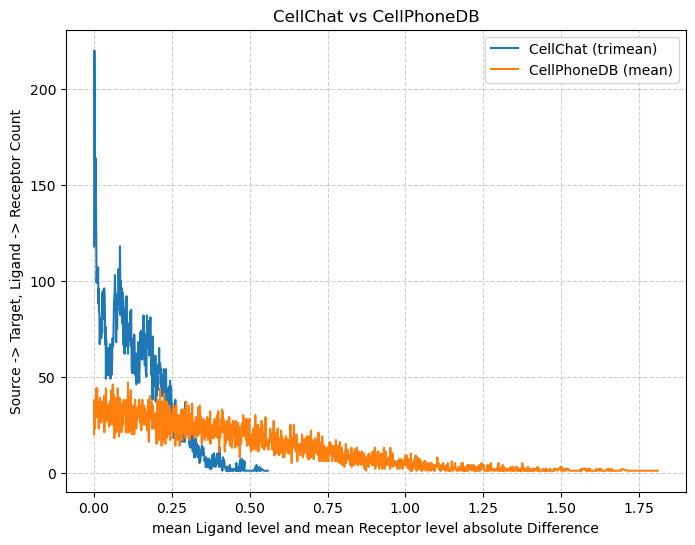

In [53]:
# Create the first histogram
# plt.figure(figsize=(8, 6))  # Adjust figure size if needed
# plt.plot(a_CellPhoneDB)
# plt.title('CellPhoneDB')
# plt.ylabel('Source -> Target, Ligand -> Receptor Count')
# plt.xlabel('Ligand Receptor absolute Difference')
# plt.grid(True, linestyle='--', alpha=0.6)
# plt.ylim(0,1100)
# plt.xlim(0,2)
# plt.show()

# # Create the second histogram
# plt.figure(figsize=(8, 6))  # Adjust figure size if needed
# plt.plot(a_CellChat) # You can change the color
# plt.title('CellChat')
# plt.ylabel('Source -> Target, Ligand -> Receptor Count')
# plt.xlabel('Ligand Receptor absolute Difference')
# plt.ylim(0,1100)
# plt.xlim(0,2)
# plt.grid(True, linestyle='--', alpha=0.6)
# plt.show()


# Create the second histogram
plt.figure(figsize=(8, 6))  # Adjust figure size if needed
plt.plot(a_CellChat, label='CellChat (trimean)') # You can change the color
plt.plot(a_CellPhoneDB, label='CellPhoneDB (mean)')
plt.title('CellChat vs CellPhoneDB')
plt.ylabel('Source -> Target, Ligand -> Receptor Count')
plt.xlabel('mean Ligand level and mean Receptor level absolute Difference')
# plt.ylim(0,1100)
# plt.xlim(0,2)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.savefig("figures/scorefct_vs.png")
plt.show()


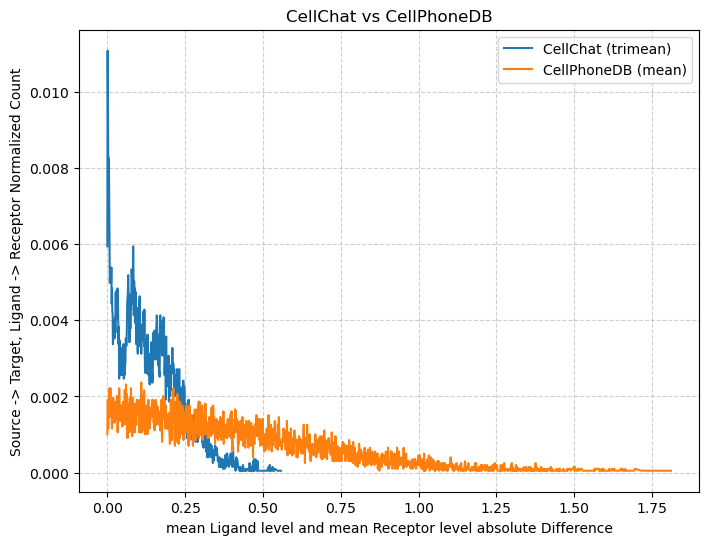

In [51]:
a_CellPhoneDB_normalized = a_CellPhoneDB / a_CellPhoneDB.sum()
a_CellChat_normalized = a_CellChat / a_CellChat.sum()

# Create the second histogram
plt.figure(figsize=(8, 6))  # Adjust figure size if needed
plt.plot(a_CellChat_normalized, label='CellChat (trimean)')
plt.plot(a_CellPhoneDB_normalized, label='CellPhoneDB (mean)')
plt.title('CellChat vs CellPhoneDB')
plt.ylabel('Source -> Target, Ligand -> Receptor Normalized Count')
plt.xlabel('mean Ligand level and mean Receptor level absolute Difference')
# plt.ylim(0,1100)
# plt.xlim(0,2)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.savefig("figures/scorefct_vs_norm.png")
plt.show()
